In [1]:
# ============================================================
# CELL 1 - Load Modeling Data & Summary
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

DATA_PATH = "../data/processed/modeling_data.csv"
df = pd.read_csv(DATA_PATH)

print("=" * 60)
print("EXPLORATORY DATA ANALYSIS")
print("=" * 60)
print("Dataset shape:", df.shape)
print("Countries:", df["country"].nunique())
print("Year range:", df["year"].min(), "-", df["year"].max())
print("Missing values:", df.isna().sum().sum())

print("\nSummary statistics:")
display(df.describe().T)

EXPLORATORY DATA ANALYSIS
Dataset shape: (1817, 16)
Countries: 79
Year range: 2000 - 2022
Missing values: 0

Summary statistics:


,count,mean,std,min,25%,50%,75%,max
co2,1817.0,3.894018e+02,1.154847e+03,2.864992e+00,4.279425e+01,9.331747e+01,3.141966e+02,1.171181e+04
year,1817.0,2.011000e+03,6.635076e+00,2.000000e+03,2.005000e+03,2.011000e+03,2.017000e+03,2.022000e+03
population_co2,1817.0,7.378757e+07,2.077922e+08,2.812930e+05,5.529616e+06,1.960036e+07,5.928810e+07,1.426437e+09
gdp_co2,1817.0,1.134676e+12,2.661526e+12,9.307402e+09,1.692262e+11,3.605170e+11,9.620958e+11,2.696602e+13
primary_energy_consumption_energy,1817.0,1.736402e+03,4.575363e+03,2.770799e+01,2.305396e+02,4.906227e+02,1.362193e+03,4.451649e+04
fossil_share_energy,1817.0,8.419012e+01,1.658273e+01,1.387364e+01,7.720554e+01,8.814314e+01,9.703559e+01,1.000000e+02
renewables_share_energy,1817.0,1.165717e+01,1.448739e+01,0.000000e+00,1.890443e+00,6.311814e+00,1.695980e+01,8.612636e+01
renewables_electricity,1817.0,5.723182e+01,1.710681e+02,0.000000e+00,2.120000e+00,1.176000e+01,3.800000e+01,2.670660e+03
renewables_share_elec,1817.0,2.533582e+01,2.608831e+01,0.000000e+00,4.986488e+00,1.584220e+01,3.935743e+01,1.000000e+02
solar_share_energy,1817.0,3.532386e-01,8.193346e-01,0.000000e+00,0.000000e+00,4.933649e-03,2.031464e-01,7.773575e+00


GLOBAL CO₂ EMISSION TREND
Lowest total CO₂ year: 2000 - 23994.6 Mt
Highest total CO₂ year: 2022 - 35369.21 Mt


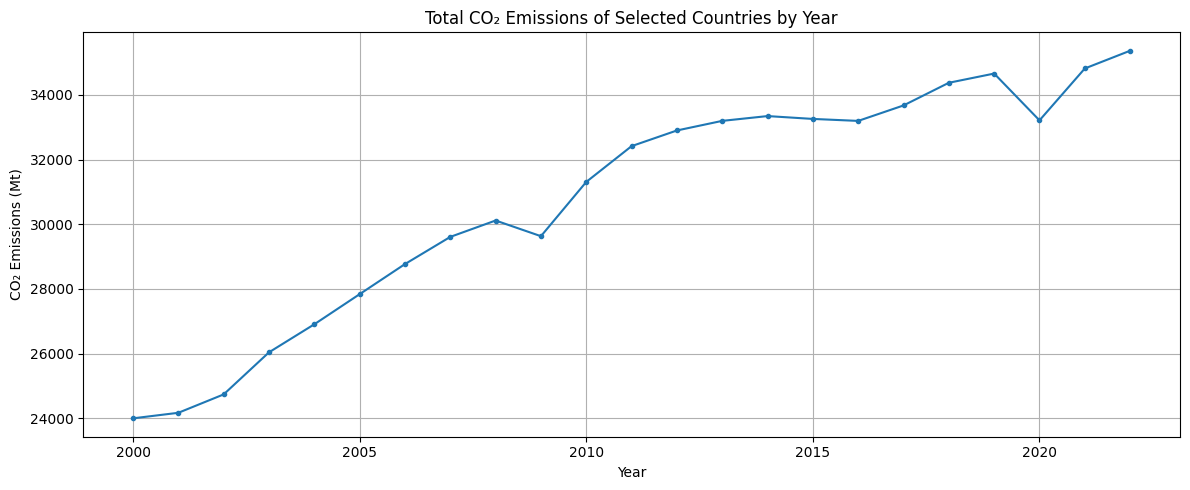

In [2]:
# ============================================================
# CELL 2 - Global CO₂ Emission Trend
# ============================================================

print("=" * 60)
print("GLOBAL CO₂ EMISSION TREND")
print("=" * 60)

yearly_co2 = df.groupby("year")["co2"].sum()

print("Lowest total CO₂ year:", yearly_co2.idxmin(), "-", round(yearly_co2.min(), 2), "Mt")
print("Highest total CO₂ year:", yearly_co2.idxmax(), "-", round(yearly_co2.max(), 2), "Mt")

plt.figure(figsize=(12, 5))
plt.plot(yearly_co2.index, yearly_co2.values, marker="o", markersize=3)
plt.xlabel("Year")
plt.ylabel("CO₂ Emissions (Mt)")
plt.title("Total CO₂ Emissions of Selected Countries by Year")
plt.grid(True)
plt.tight_layout()
plt.show()

COUNTRY CO₂ COMPARISON
Top 15 CO₂ emitters in 2022


,country,co2
298,China,11711.807617
1747,United States,5055.402832
666,India,2831.131592
1310,Russia,1675.460815
827,Japan,1029.644897
712,Iran,767.178467
689,Indonesia,758.020508
551,Germany,667.843018
1333,Saudi Arabia,666.993530
1448,South Korea,606.877258


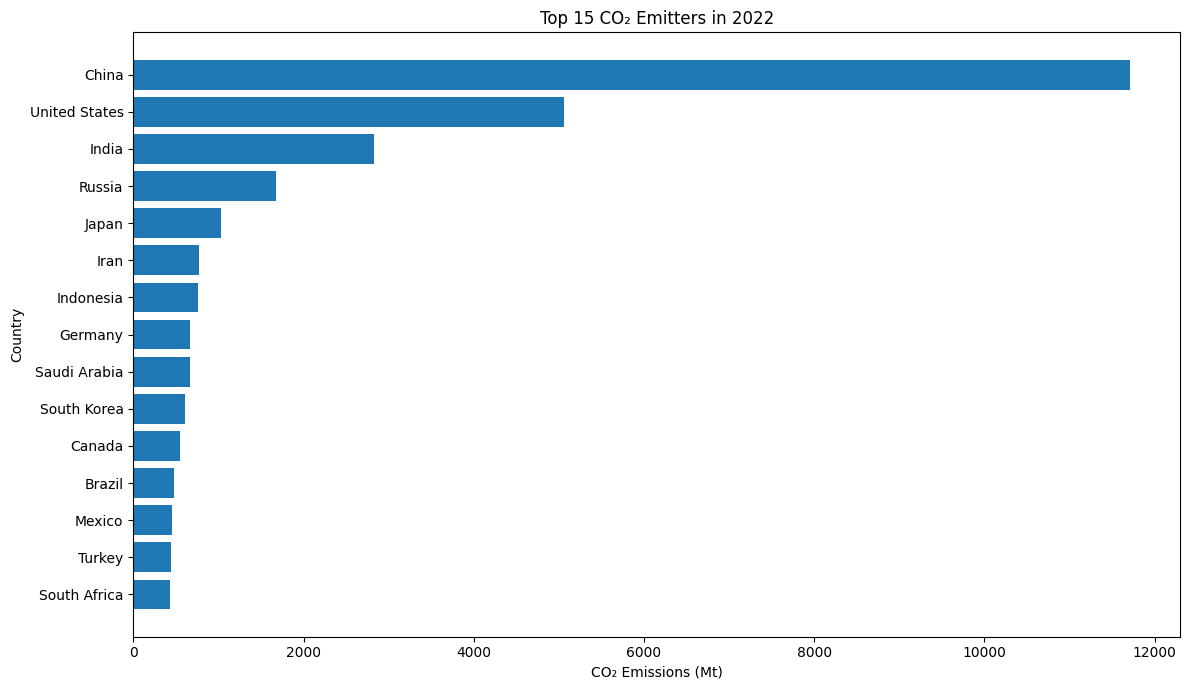

In [3]:
# ============================================================
# CELL 3 - Country CO₂ Comparison
# ============================================================

print("=" * 60)
print("COUNTRY CO₂ COMPARISON")
print("=" * 60)

latest_year = df["year"].max()
latest = df[df["year"] == latest_year].sort_values("co2", ascending=False).head(15)

print("Top 15 CO₂ emitters in", latest_year)
display(latest[["country", "co2"]])

plt.figure(figsize=(12, 7))
plt.barh(latest["country"][::-1], latest["co2"][::-1])
plt.xlabel("CO₂ Emissions (Mt)")
plt.ylabel("Country")
plt.title(f"Top 15 CO₂ Emitters in {latest_year}")
plt.tight_layout()
plt.show()

ENERGY, GDP & RENEWABLE RELATIONSHIPS
CO₂ vs Primary Energy: correlation = 0.9874
CO₂ vs GDP: correlation = 0.9461
CO₂ vs Renewable Share: correlation = -0.0772
CO₂ vs Renewable Electricity: correlation = 0.8484


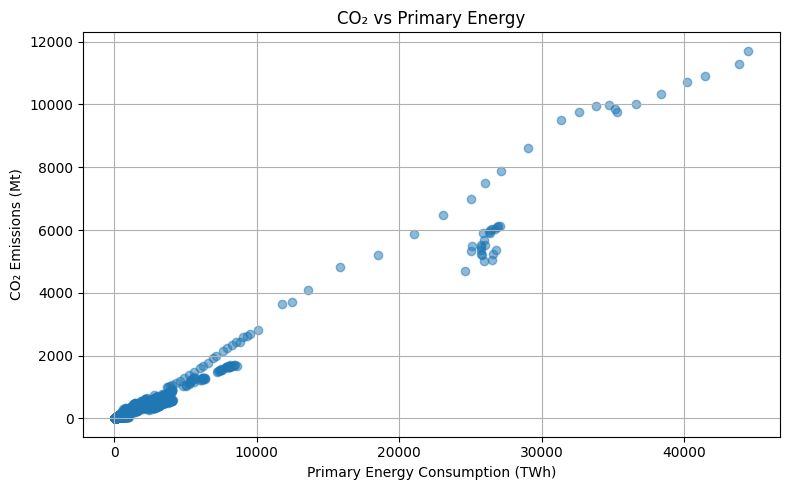

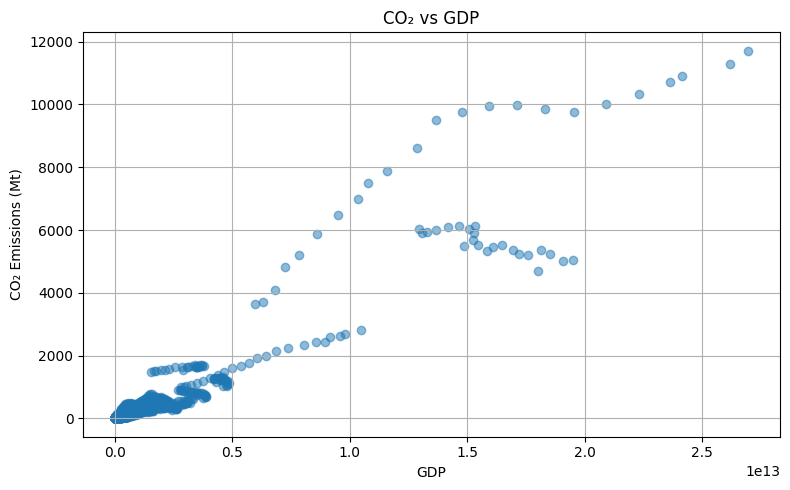

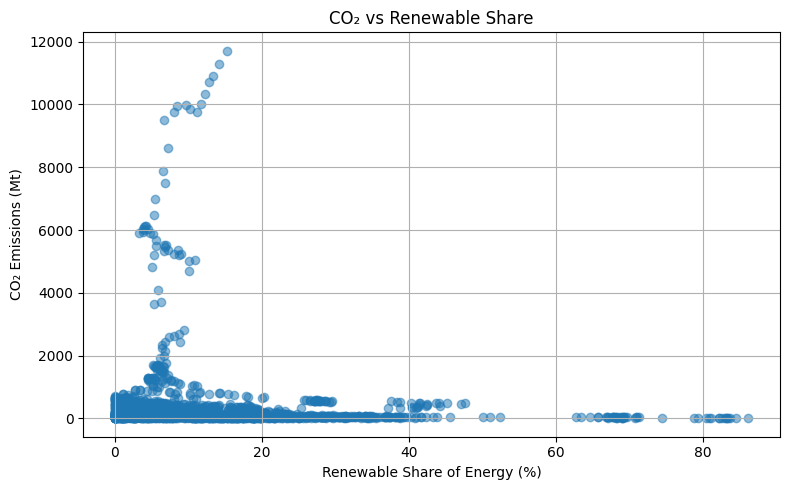

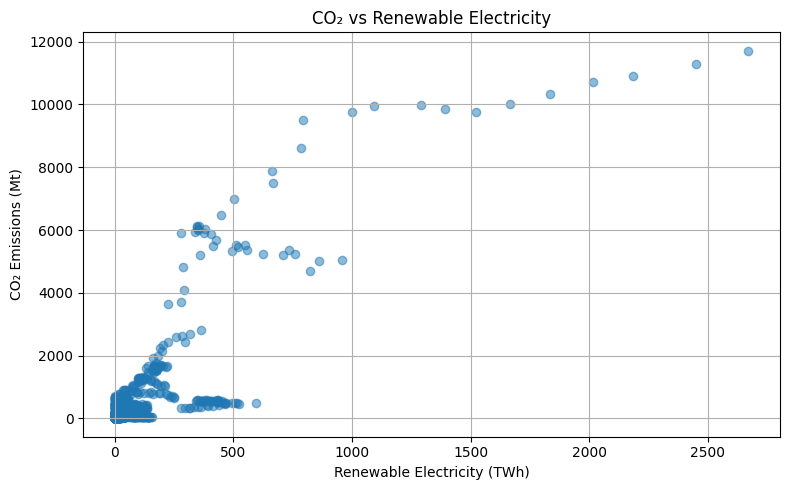

In [4]:
# ============================================================
# CELL 4 - Energy, GDP & Renewable Relationships
# ============================================================

print("=" * 60)
print("ENERGY, GDP & RENEWABLE RELATIONSHIPS")
print("=" * 60)

relationships = {
    "CO₂ vs Primary Energy": "primary_energy_consumption_energy",
    "CO₂ vs GDP": "gdp_co2",
    "CO₂ vs Renewable Share": "renewables_share_energy",
    "CO₂ vs Renewable Electricity": "renewables_electricity"
}

for title, feature in relationships.items():
    corr = df["co2"].corr(df[feature])
    print(f"{title}: correlation = {corr:.4f}")

figures = [
    ("CO₂ vs Primary Energy", "primary_energy_consumption_energy", "Primary Energy Consumption (TWh)"),
    ("CO₂ vs GDP", "gdp_co2", "GDP"),
    ("CO₂ vs Renewable Share", "renewables_share_energy", "Renewable Share of Energy (%)"),
    ("CO₂ vs Renewable Electricity", "renewables_electricity", "Renewable Electricity (TWh)")
]

for title, feature, xlabel in figures:
    plt.figure(figsize=(8, 5))
    plt.scatter(df[feature], df["co2"], alpha=0.5)
    plt.xlabel(xlabel)
    plt.ylabel("CO₂ Emissions (Mt)")
    plt.title(title)
    plt.grid(True)
    plt.tight_layout()
    plt.show()

CORRELATION & RENEWABLE ENERGY ANALYSIS
Variables most correlated with CO₂:


,correlation
co2,1.000000
primary_energy_consumption_energy,0.987365
gdp_co2,0.946075
renewables_electricity,0.848423
population_co2,0.752524
fossil_share_energy,0.063204
solar_share_energy,0.049452
year,0.037333
wind_share_energy,0.004334
energy_per_capita,-0.004807


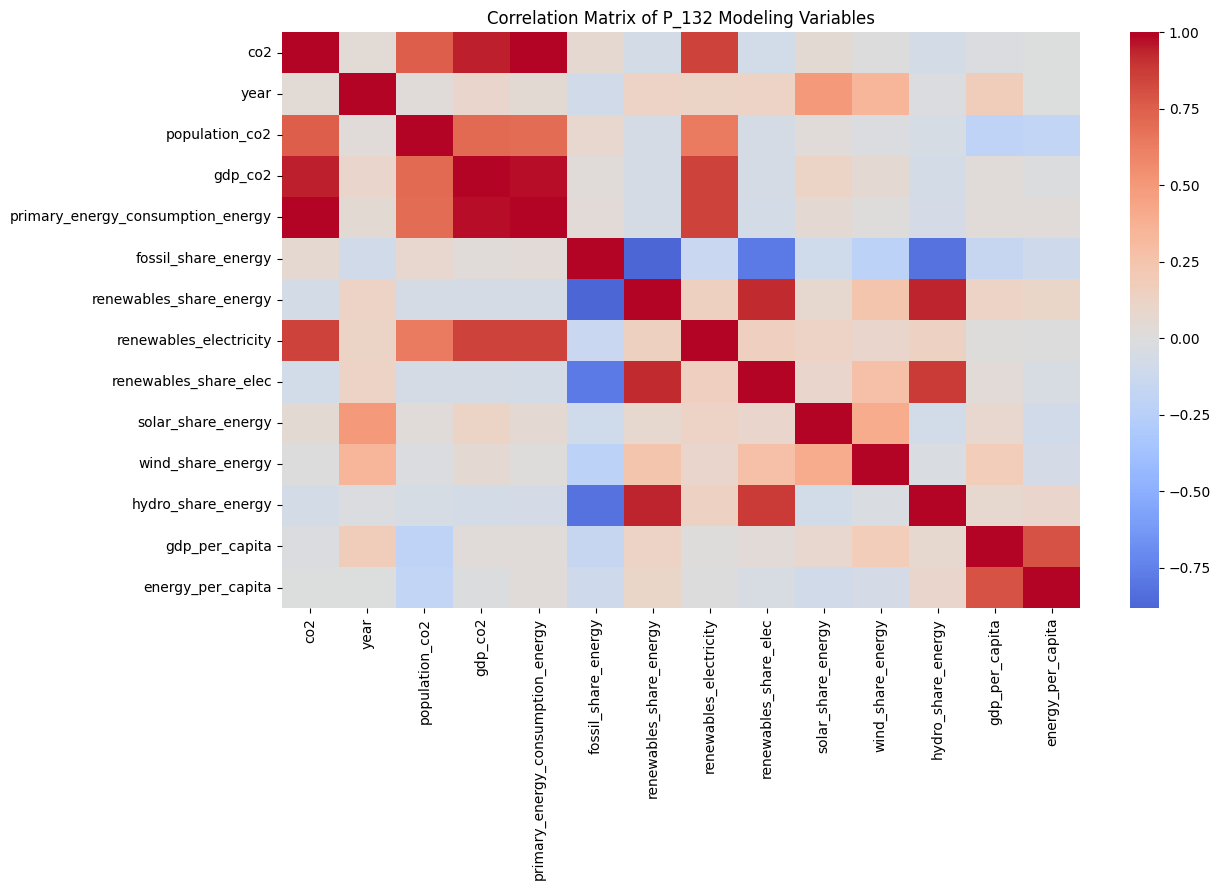

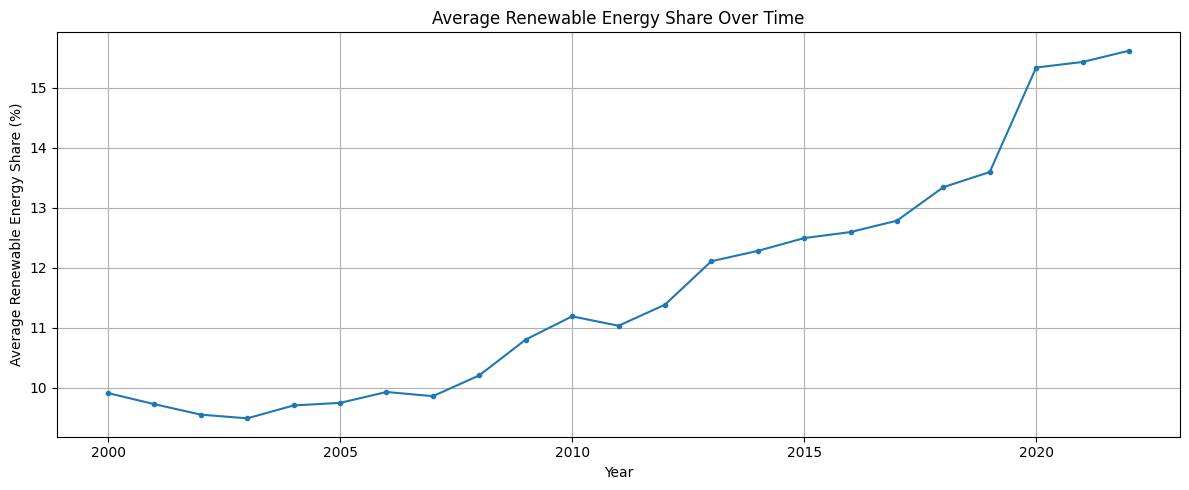

In [5]:
# ============================================================
# CELL 5 - Correlation & Renewable Energy Analysis
# ============================================================

print("=" * 60)
print("CORRELATION & RENEWABLE ENERGY ANALYSIS")
print("=" * 60)

numeric_columns = df.select_dtypes(include=np.number).columns
correlation = df[numeric_columns].corr()

print("Variables most correlated with CO₂:")
display(correlation["co2"].sort_values(ascending=False).to_frame("correlation"))

plt.figure(figsize=(13, 9))
sns.heatmap(correlation, cmap="coolwarm", center=0, annot=False)
plt.title("Correlation Matrix of P_132 Modeling Variables")
plt.tight_layout()
plt.show()

renewable_trend = df.groupby("year")["renewables_share_energy"].mean()

plt.figure(figsize=(12, 5))
plt.plot(renewable_trend.index, renewable_trend.values, marker="o", markersize=3)
plt.xlabel("Year")
plt.ylabel("Average Renewable Energy Share (%)")
plt.title("Average Renewable Energy Share Over Time")
plt.grid(True)
plt.tight_layout()
plt.show()